# Bayesian calibration of a chiral effective field theory for light nuclei

Bayesian parameter estimation, MCMC sampling and model checking for the
three-nucleon low-energy constants $(c_D, c_E)$ of chiral effective field
theory, using a fast emulator of few-nucleon observables.

*Course project in* Learning from Data *(TIF285), Chalmers University of
Technology, Fall 2026. The project description, the physics background, the
emulator (`quantumsolver.py`) and the data (`evcData/`) were provided by the
course. Everything else in this notebook (the implementation of the analysis,
the figures and their interpretation) is original work.*

<a id="toc"></a>
## Table of contents

- [Overview](#overview)
- [Physics background](#background)
- [Setup: the emulator and the data](#setup)
- [1. Prior predictive check](#prior)
- [2. Information content of individual observables](#single)
- [3. MCMC sampling of the posterior](#mcmc)
- [4. Posterior predictive distribution](#ppd)
- [5. Inferring the error model](#errormodel)

<a id="overview"></a>
## Overview

### The problem
This is a common scenario in scientific modeling: a physics model has unknown
parameters, and its outputs can be compared with measured data. The goal is to
infer the parameters from the data while accounting for all relevant sources of
uncertainty, to check that the calibrated model is consistent, and then to use
it for predictions.

Here the model describes atomic nuclei starting from chiral effective field
theory (EFT). It computes the binding energies ($E$) of $^3$H, $^3$He and
$^4$He, the point-proton radius ($R_p$) of $^4$He and the comparative
beta-decay half-life ($fT$) of $^3$H. The two unknown parameters, $c_D$ and
$c_E$, are low-energy constants of the three-nucleon force.

The full model (the **simulator**) solves a large-scale eigenvalue problem and
takes about a minute per evaluation, which is far too slow for a statistical
analysis. It is therefore replaced by an **emulator**, a reduced-order model
that reproduces its output in well under a millisecond.

The analysis follows Sec. II of the paper
[*Rigorous constraints on three-nucleon forces in chiral effective field theory
from fast and accurate calculations of few-body
observables*](https://arxiv.org/abs/2104.04441) by Wesolowski *et al.*, with a
slightly different model and some additional approximations. The results are
therefore not expected to match the paper exactly, in particular for the
inferred parameter values.

### What this notebook does
1. **Prior predictive check**: what does a "natural-size" prior on
   $(c_D, c_E)$ imply for the observables?
2. **Information content of individual observables**: single-datum posteriors
   evaluated on a grid, with and without a model-discrepancy term (the EFT
   truncation error).
3. **MCMC sampling** of the posterior with `emcee` for two data sets, with
   convergence diagnostics (trace plots, autocorrelation times).
4. **Posterior predictive distribution**, as a check of the calibrated model
   against experiment.
5. **Inferring the error model**: the EFT expansion parameter $Q$ is sampled
   together with $(c_D, c_E)$, so that the size of the model discrepancy is
   learned from the data.

### Main results
- The prior looks weakly informative for the parameters, but it is strongly
  informative for the observables: 38% of the prior predictive samples bind
  $^4$He more than three times as deeply as in reality.
- Without the EFT truncation error, no single $(c_D, c_E)$ reproduces all four
  observables. Once it is included, the observables become mutually
  consistent.
- $E(^4\mathrm{He})$ and $R_p(^4\mathrm{He})$ alone only constrain one
  combination of the parameters (correlation 0.995). Adding the $^3$H data,
  in particular the beta decay, constrains both:
  $c_D = 1.17 \pm 0.47$ and $c_E = 0.016 \pm 0.08$.
- The calibrated model reproduces all four observables within
  $1.6\,\sigma_\mathrm{total}$. The largest tension is the $^4$He radius.
- When $Q$ is sampled, its posterior is much narrower than its prior (68%
  interval $[0.32, 0.42]$) and peaks close to the value $Q = 0.33$ used in
  Sections 2–4, while the parameter posterior develops the heavy tails reported
  in the paper.


<div style="text-align: right"><a href="#toc">&#8593; Table of contents</a></div>

<a id="background"></a>
## Physics background
*(Adapted from the course material.)*

The modeling of hadronic systems, such as atomic nuclei, involves a theoretical
description of the strong interaction. At a very fundamental level, such a
description involves quarks and gluons within a quantum field theory
known as quantum chromodynamics (QCD). This theory of the strong force is included in the standard model of
particle physics. However, at low energies, quarks condense into hadrons and the
fully resolved QCD description becomes intractable. Instead, an effective theory can be
constructed in which neutrons, protons (and possibly other hadrons) are used as
effective degrees of freedom. The most general interaction between these
particles, consistent with the symmetries of the underlying theory, can be
formulated using the framework of effective field theory (EFT). The model used
here is based on a so called chiral EFT, which utilizes the
spontaneously broken chiral symmetry of QCD.

Important, general aspects of EFTs are:
- An EFT includes an infinite number of interaction diagrams. However, they can
  be ordered by importance using a so called power counting. This gives an EFT
  expansion for which the expansion parameter, $Q$, is an important property as
  it sets the convergence rate.
- Many diagrams are associated with unknown parameters, so called low-energy
  constants (LECs), that must be inferred.
- Predictions can be made at a certain truncation of the EFT expansion. Such a 
  truncated-model prediction will be associated with a truncation error, which can be quantified using our knowledge of the EFT expansion.

#### Chiral EFT for nuclei
Atomic nuclei can be modeled as strongly interacting, quantum many-body systems.
Using a non-relativistic approximation, the truncated chiral EFT description
gives an interaction potential
$$
V^k(\vec\theta) = V^k_{N\!N}(\vec\theta_{N\!N}) + V^k_{3N}(\vec\theta_{3N}) + \ldots,
$$
where $k$ is the chiral expansion order, $\vec\theta$ is the vector of LECs
(model parameters), and the unresolved short-distance physics leads to the
appearance of irreducible higher-body forces. In this particular case, we will
be considering a scenario where we are operating at $k=3$, known as
next-to-next-to-leading order (NNLO), at which three-nucleon forces appear for
the first time. We will also make the simplifying assumption that LECs
associated with two-nucleon diagrams have already been inferred to infinite
precision. This implies that the parameters $\vec\theta_{N\!N}$ are known, but
that $\vec\theta_{3N}$ remains to be determined. The parameter vector
$\vec\theta_{3N}$ consists of two LECs that are known as $(c_D, c_E)$. The
analysis performed in Wesolowski's paper is more involved as it includes a prior
uncertainty in $\vec\theta_{N\!N}$. This will not be considered here.

#### Solving the nuclear many-body problem
We are interested in solving the non-relativistic Schrödinger equation
$H \Psi = E \Psi$ for a many-body system. The Hamiltonian contains the
chiral EFT potential plus kinetic energy terms. The eigenvalue $E$ corresponds
to the total energy of the system, whereas expectation values of other operators
give further observables such as radii and transition strengths.

The solution of the many-body Schrödinger equation can be approached by
constructing a single-particle basis and using the formalism of second
quantization to obtain a basis for the many-body system under consideration.
Projecting the Hamiltonian operator on this (high-dimensional) basis leads to a
large-scale eigenvalue problem that can be solved iteratively. For the
few-nucleon systems considered here the Hamiltonian matrix can be of size
$N \times N$ with $N \approx 10^5$.

#### Eigenvector continuation emulators
Using an eigensolver developed at Chalmers, the lowest eigenvalues and
corresponding eigenstates of $A=3,4$ systems can be found using Lanczos
diagonalization in $\approx 60$ seconds. While this is good, it is still not
enough for a statistical analysis in which the parameter values are changed
and the problem is solved many times. The analysis therefore uses a
reduced-order model that mimics the full solution in just a fraction of the time
(milliseconds rather than minutes). It relies on a technique known
as eigenvector continuation (EC) that finds an optimal basis and translates the
large-scale ($N \approx 10^5$) eigenvalue problem into a small-scale
($N_{EC} \approx 10$) generalized eigenvalue problem. The emulators are
described in Sec. III.B of the paper with some relevant references for the
interested reader.


<div style="text-align: right"><a href="#toc">&#8593; Table of contents</a></div>

<a id="setup"></a>
## Setup: the emulator and the data

The emulator module `quantumsolver.py` and the data directory `evcData/` are
provided by the course and must sit in the same directory as this notebook for
the import below to work.


<div style="text-align: right"><a href="#toc">&#8593; Table of contents</a></div>

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

import warnings
with warnings.catch_warnings():
    # corner imports arviz, which emits a one-per-day FutureWarning about an
    # upcoming refactor. Nothing here is affected by it.
    warnings.simplefilter("ignore", FutureWarning)
    import emcee
    import corner

import quantumsolver as qs

rng = np.random.default_rng(seed=2026)

### The emulator

The physics model is the function `qs.fewnucleonEmulator(cD, cE)`. Its
docstring (`help(qs.fewnucleonEmulator)`) lists the seven outputs and their
units. As a check that everything works, the cell below evaluates the emulator
at the NNLO$_\mathrm{sat}$ parameter values. The reference output is

```
  E4He:     -28.4233
 Rp4He:       1.4824
Rch4He:       1.6987
  E3He:      -7.7596
   E3H:      -8.5175
 E1A3H:       0.6794
  fT3H:    1144.0855
```

(The emulator solves small generalized eigenvalue problems, so the very last
digits depend on the linear-algebra library.)

[Credit to Andreas Ekström (Dept. of Physics, Chalmers) for producing the EVC
emulator that is used in `fewnucleonEmulator`.]

In [2]:
# The names of the seven emulator outputs, in the order they are returned
model_output_names = ['E4He', 'Rp4He', 'Rch4He', 'E3He', 'E3H', 'E1A3H', 'fT3H']

model_NNLOsat = qs.fewnucleonEmulator(qs.cD_NNLOsat, qs.cE_NNLOsat)
for name, value in zip(model_output_names, model_NNLOsat):
    print(f'{name:>6}: {value:>12.4f}')

  E4He:     -28.4233
 Rp4He:       1.4824
Rch4He:       1.6987
  E3He:      -7.7596
   E3H:      -8.5175
 E1A3H:       0.6794
  fT3H:    1144.0855


The emulator input is a single $(c_D, c_E)$ pair. To avoid Python `for` loops when
evaluating the model on a grid, or for a set of MCMC samples, we use the
vectorized version created below with `np.vectorize`. Note that this is a
convenience wrapper rather than a speed-up: it still calls the emulator once per
parameter pair.

In [3]:
# Vectorized version of the few-nucleon emulator
vfewnucleonEmulator = np.vectorize(qs.fewnucleonEmulator)

# Illustration on a small 2x2 grid
cD_test, cE_test = np.meshgrid(np.array([-2.5, 2.5]), np.array([-1., 1.]))
print('cD_test is of shape:', cD_test.shape)
print(cD_test)

# The vectorized emulator returns a tuple with one array per output, each of
# the same shape as the input.
test_output = vfewnucleonEmulator(cD_test, cE_test)
print('the E4He output is of shape:', test_output[0].shape)
print(test_output[0])

cD_test is of shape: (2, 2)
[[-2.5  2.5]
 [-2.5  2.5]]
the E4He output is of shape: (2, 2)
[[ -24.40247682  -21.37114724]
 [-105.55765698  -40.33178611]]


<a id="data"></a>
### The data and the error model

The experimental values and the adopted errors are taken from Table I of the
paper. The adopted errors quantify the combination of the experimental error and
the estimated precision of the many-body solver; the theoretical error from the
truncation of the EFT expansion is introduced in Section 2.



<div style="text-align: right"><a href="#toc">&#8593; Table of contents</a></div>

In [4]:
# Experimental targets and adopted (experiment + method) errors, from Table I of
# the paper. They are used throughout the analysis.
exp_target = {'E4He': -28.296, 'Rp4He': 1.4552, 'E3H': -8.482, 'fT3H': 1129.6}
exp_method_error = {'E4He': 0.005, 'Rp4He': 0.0062, 'E3H': 0.015, 'fT3H': 3.0}

<a id="prior"></a>
## 1. Prior predictive check

The parameters $c_D, c_E$ can be positive or negative, but are expected to be of
natural size ($\sim 1$). We encode this expectation into the prior
$$
p(c_D, c_E | I) = \mathcal{N}(c_D; 0, 5^2) \, \mathcal{N}(c_E; 0, 5^2),
$$
that is, independent normal distributions with mean zero and standard deviation
$\sigma=5$. This prior is used throughout the analysis.

*Notation*: we write $\mathcal{N}(x; \mu, \sigma^2)$ for the normal probability
density of the variable $x$, with mean $\mu$ and **variance** $\sigma^2$, and
$x \sim \mathcal{N}(\mu, \sigma^2)$ when $x$ is a draw from that distribution.
Note that `scipy.stats.norm` instead takes the standard deviation $\sigma$ as
its `scale` argument.

Before using the data it is worth checking what this prior implies about the
observables themselves. Evaluating the model for parameters drawn from the prior
gives the **prior predictive distribution**: a distribution over predicted data
rather than over parameters.

In this section we
- draw $10^4$ samples of $(c_D, c_E)$ from the prior and evaluate the model for
  each of them (no MCMC is needed: the prior is a product of independent normal
  distributions, so it can be sampled directly);
- plot the marginal prior predictive distributions for $E(^4\mathrm{He})$ and
  $fT(^3\mathrm{H})$ together with the experimental values;
- compute the fraction of samples with $E(^4\mathrm{He}) < -100$ MeV (an alpha
  particle more than three times as deeply bound as the real one) and with
  $E(^4\mathrm{He}) > 0$ (an unbound $^4\mathrm{He}$);
- check whether a prior that is weakly informative in *parameter* space is also
  weakly informative in *observable* space, and whether a narrower prior would
  change the posterior of Section 3, by comparing the width of the prior
  predictive distribution with the errors $\sigma_{\mathrm{exp+method},i}$.


<div style="text-align: right"><a href="#toc">&#8593; Table of contents</a></div>

In [5]:
# Prior predictive distribution: draw parameters from the prior and evaluate the
# model for each draw.
prior_sigma = 5.
n_prior_samples = 10**4

# The prior is a product of independent normal distributions, so it can be
# sampled directly (no MCMC needed).
cD_prior = rng.normal(loc=0., scale=prior_sigma, size=n_prior_samples)
cE_prior = rng.normal(loc=0., scale=prior_sigma, size=n_prior_samples)

# One array of length n_prior_samples per emulator output
prior_predictive = dict(zip(model_output_names,
                            vfewnucleonEmulator(cD_prior, cE_prior)))

E4He_prior = prior_predictive['E4He']
print(f'Fraction with E(4He) < -100 MeV   : {np.mean(E4He_prior < -100):.4f}')
print(f'Fraction with E(4He) > 0 (unbound): {np.mean(E4He_prior > 0):.4f}')
print(f'Fraction within 1 MeV of experiment: '
      f'{np.mean(np.abs(E4He_prior - exp_target["E4He"]) < 1):.4f}')
print(f'Range of E(4He) among the samples : '
      f'[{E4He_prior.min():.1f}, {E4He_prior.max():.1f}] MeV')

Fraction with E(4He) < -100 MeV   : 0.3822
Fraction with E(4He) > 0 (unbound): 0.0000
Fraction within 1 MeV of experiment: 0.0148
Range of E(4He) among the samples : [-1931.4, -9.3] MeV


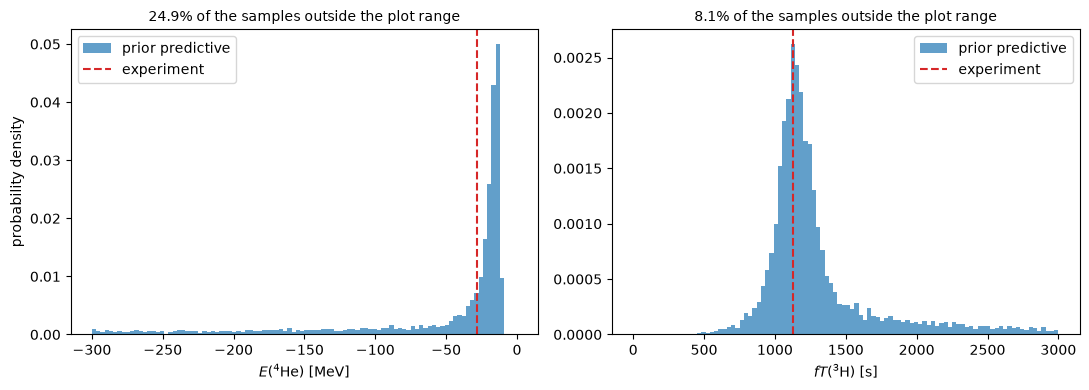

In [6]:
# Marginal prior predictive distributions for E(4He) and fT(3H), with the
# experimental value marked. The distributions have long tails, so the plot
# ranges are chosen by hand and the fraction of samples outside is reported.
# The histograms are normalized to the full sample, not only to the part shown.
plot_ranges = {'E4He': (-300., 0.), 'fT3H': (0., 3000.)}
xlabels = {'E4He': r'$E(^4\mathrm{He})$ [MeV]', 'fT3H': r'$fT(^3\mathrm{H})$ [s]'}
n_bins = 100

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axs, plot_ranges):
    lo, hi = plot_ranges[name]
    samples = prior_predictive[name]
    bin_width = (hi - lo) / n_bins
    fraction_outside = np.mean((samples < lo) | (samples > hi))
    ax.hist(samples, bins=n_bins, range=(lo, hi),
            weights=np.full(n_prior_samples, 1. / (n_prior_samples * bin_width)),
            color='C0', alpha=0.7, label='prior predictive')
    ax.axvline(exp_target[name], color='C3', ls='--', label='experiment')
    ax.set_xlabel(xlabels[name])
    ax.set_title(f'{100 * fraction_outside:.1f}% of the samples outside the plot range',
                 fontsize=10)
    ax.legend()
axs[0].set_ylabel('probability density')
fig.tight_layout()

In [7]:
# Compare the width of the prior predictive distribution with the errors
# sigma_exp+method. As a measure of the width we use the central 68% interval
# (16th to 84th percentile), which is robust to the long tails.
print(f"{'':>6} {'16%':>10} {'median':>10} {'84%':>10} {'68% width':>10} "
      f"{'sigma_exp+meth':>15} {'ratio':>9}")
for name in exp_target:
    p16, p50, p84 = np.percentile(prior_predictive[name], [16, 50, 84])
    width = p84 - p16
    sigma = exp_method_error[name]
    print(f'{name:>6} {p16:>10.3f} {p50:>10.3f} {p84:>10.3f} {width:>10.3f} '
          f'{sigma:>15.4f} {width / sigma:>9.1e}')

              16%     median        84%  68% width  sigma_exp+meth     ratio
  E4He   -489.956    -32.171    -14.644    475.312          0.0050   9.5e+04
 Rp4He      0.783      1.407      1.880      1.097          0.0062   1.8e+02
   E3H    -75.552     -9.025     -5.256     70.297          0.0150   4.7e+03
  fT3H   1042.405   1194.123   1945.566    903.161          3.0000   3.0e+02


#### Interpretation

**The prior predictive distributions.** Both distributions are very broad and
strongly skewed. For $E(^4\mathrm{He})$ most samples lie between about $-50$ and
$-10$ MeV (median $-32$ MeV), but there is a long tail towards deep binding that
reaches almost $-2000$ MeV; a quarter of the samples fall below the $-300$ MeV
edge of the plot. The $fT(^3\mathrm{H})$ distribution peaks close to the
experimental value (median $\approx 1190$ s), but its central 68% interval is
still $\approx 900$ s wide, with a tail beyond $6000$ s.

**The fractions.** 38% of the samples give $E(^4\mathrm{He}) < -100$ MeV, i.e.
an alpha particle more than three times as deeply bound as the real one. None of
the samples gives an unbound $^4\mathrm{He}$: the least bound sample has
$E \approx -9$ MeV. Many of the samples have $|c_D|$ or $|c_E|$ of 5–10, far from the
$\mathrm{NNLO}_\mathrm{sat}$ point where the emulator was trained, so the precise fractions
are extrapolations. The qualitative picture does not depend on them.

**Is the prior weakly informative in observable space?** No. In parameter space
it only states that the LECs are of natural size. Mapped through the non-linear
model, however, it makes a strong and very asymmetric statement about the
observables: 38% probability for an alpha particle bound by more than 100 MeV,
and only about 1.5% of the samples within 1 MeV of the measured binding energy.
A prior that looks mild for the parameters is not automatically mild for the
predictions.

**Would a narrower prior change the posterior of Section 3?** The table above shows
that the central 68% interval of the prior predictive distribution is
$10^2$–$10^5$ times wider than $\sigma_{\mathrm{exp+method},i}$ (e.g.
$\approx 475$ MeV compared with $0.005$ MeV for $E(^4\mathrm{He})$). The data
are therefore far more informative than the prior. In the directions of
$(c_D, c_E)$ that the data constrain, the likelihood confines the parameters to
a region that is small compared with the prior width, and the prior is almost
constant over that region. Narrowing the prior moderately should therefore not
change the posterior noticeably, as long as it stays wide compared with the
posterior and does not push against the region the data select. The exception is
a direction that the data do *not* constrain. With only two observables of the
same nucleus (Case 1) we expect such an almost degenerate direction, along
which the data constrain the parameters only weakly, so a narrower prior would
matter there. With all four observables (Case 2) both directions should be
constrained, and the prior should play a minor role.

<a id="single"></a>
## 2. Information content of individual observables

To study how strongly each of the four observables of Table I of the paper
(E4He, Rp4He, E3H, fT3H) constrains the parameters
$(c_D, c_E) \equiv \vec\theta_{3N}$, we compute the four posteriors
$$
p(c_D, c_E | y_{\mathrm{exp},i}, \sigma_i, I ) \propto p(y_{\mathrm{exp},i} | c_D, c_E, \sigma_i, I) p(c_D, c_E | I ),
$$
each conditional on a single datum
$y_{\mathrm{exp},i} \in \{\text{E4He, Rp4He, E3H, fT3H}\}$ and on the
associated error model represented by $\sigma_i, I$, with the prior of
Section 1. They are evaluated on a grid $c_D \in [-2.5, 2.5]$,
$c_E \in [-1.0, 1.0]$ and correspond to Figs. 6a and 6b of the paper. Because
of the differences in the underlying model and approximations, the results, and
in particular the MAP point, differ from the paper.

Each likelihood is a normal distribution
$$
p(y_{\mathrm{exp},i} | c_D, c_E, \sigma_i, I) = \mathcal{N} \left( y_{\mathrm{exp},i}; \, y_{\mathrm{th},i}(c_D, c_E), \, \sigma_i^2 \right).
$$
That is, the density is evaluated at the observed, experimental value
$y_{\mathrm{exp},i}$; its mean is the model prediction
$y_{\mathrm{th},i}(c_D, c_E)$ for that observable; and its variance
$\sigma_i^2$ reflects the combined experimental and theoretical uncertainties.

Two error models are compared:
- **(a)** only the adopted errors of Table I, $\sigma_i = \sigma_{\mathrm{exp+method},i}$
  (`exp_method_error` above), which combine the experimental error and the
  estimated precision of the many-body solver;
- **(b)** an additional model-discrepancy term that quantifies the uncertainty
  from the truncation of the EFT expansion, so that the total variance becomes
  $\sigma_i^2 = \sigma_{\mathrm{exp+method},i}^2 + \sigma_{\mathrm{EFT},i}^2$.
  Following the paper, the truncation error is estimated as
$$
\sigma_{\mathrm{EFT},i}^2 = \frac{ \left( y_{\mathrm{ref},i} \, \bar{c} \, Q^{k+1} \right)^2}{1 - Q^2},
$$
  where $k=3$ is the EFT order at which we truncate, $\bar{c}=1$, the expansion
  parameter is $Q=0.33$, and the experimental value is used as the reference
  scale, $y_{\mathrm{ref},i} = y_{\mathrm{exp},i}$.


<div style="text-align: right"><a href="#toc">&#8593; Table of contents</a></div>

In [8]:
# Evaluate the model on a grid in (cD, cE).
# One emulator call takes ~60 microseconds, so 10^6 grid points take about a
# minute. An 801 x 801 grid (~40 s) is a reasonable compromise.
import time

n_grid = 801
cD_grid_1d = np.linspace(-2.5, 2.5, n_grid)
cE_grid_1d = np.linspace(-1.0, 1.0, n_grid)
# Arrays of shape (n_grid, n_grid): rows correspond to cE, columns to cD
cD_grid, cE_grid = np.meshgrid(cD_grid_1d, cE_grid_1d)

start = time.perf_counter()
model_grid = dict(zip(model_output_names, vfewnucleonEmulator(cD_grid, cE_grid)))
elapsed = time.perf_counter() - start
print(f'{cD_grid.size} model evaluations in {elapsed:.1f} s '
      f'({1e6 * elapsed / cD_grid.size:.0f} microseconds each)')
print(f'grid spacing: dcD = {cD_grid_1d[1] - cD_grid_1d[0]:.5f}, '
      f'dcE = {cE_grid_1d[1] - cE_grid_1d[0]:.5f}')

641601 model evaluations in 40.1 s (62 microseconds each)
grid spacing: dcD = 0.00625, dcE = 0.00250


In [9]:
# The prior for (cD, cE), evaluated on the grid.
log_prior_grid = (stats.norm.logpdf(cD_grid, loc=0., scale=prior_sigma)
                  + stats.norm.logpdf(cE_grid, loc=0., scale=prior_sigma))

# The grid covers only a small part of the prior, which is therefore almost
# flat over it.
print(f'max/min of the prior on the grid: '
      f'{np.exp(log_prior_grid.max() - log_prior_grid.min()):.3f}')

max/min of the prior on the grid: 1.156


In [10]:
# The EFT truncation error at NNLO (k=3), with cbar = 1, Q = 0.33 and
# yref = yexp.
def eft_truncation_error(y_ref, Q=0.33, cbar=1., k=3):
    """Standard deviation of the EFT truncation error at chiral order k."""
    return np.abs(y_ref) * cbar * Q**(k + 1) / np.sqrt(1 - Q**2)

sigma_EFT = {name: eft_truncation_error(y) for name, y in exp_target.items()}
# Total error, with the truncation error added in quadrature
sigma_total = {name: np.sqrt(exp_method_error[name]**2 + sigma_EFT[name]**2)
               for name in exp_target}

units = {'E4He': 'MeV', 'Rp4He': 'fm', 'E3H': 'MeV', 'fT3H': 's'}
print(f"{'':>6} {'sigma_exp+method':>17} {'sigma_EFT':>10} {'sigma_total':>12}")
for name in exp_target:
    print(f'{name:>6} {exp_method_error[name]:>17.4f} {sigma_EFT[name]:>10.4f} '
          f'{sigma_total[name]:>12.4f}  {units[name]}')

        sigma_exp+method  sigma_EFT  sigma_total
  E4He            0.0050     0.3555       0.3555  MeV
 Rp4He            0.0062     0.0183       0.0193  fm
   E3H            0.0150     0.1066       0.1076  MeV
  fT3H            3.0000    14.1911      14.5048  s


In [11]:
# Tools for the single-observable posteriors on the grid.
def contour_levels(pdf, credibility):
    """Iso-probability levels of a pdf evaluated on a uniform grid.

    For each credibility c, returns the density value such that the region
    where pdf >= value holds a fraction c of the probability on the grid.
    """
    p = np.sort(pdf.ravel())[::-1]
    cumulative = np.cumsum(p) / p.sum()
    return np.array([p[np.searchsorted(cumulative, c)] for c in credibility])

def grid_posterior(name, sigma):
    """Unnormalized posterior for (cD, cE) conditional on the single datum `name`."""
    log_post = (stats.norm.logpdf(exp_target[name], loc=model_grid[name], scale=sigma)
                + log_prior_grid)
    return np.exp(log_post - log_post.max())

def grid_step_in_sigmas(name, sigma):
    """Typical change of the model output between neighbouring grid points, in units of sigma."""
    y = model_grid[name]
    step = np.maximum(np.abs(np.diff(y, axis=0))[:, :-1],
                      np.abs(np.diff(y, axis=1))[:-1, :])
    return np.median(step) / sigma

error_models = {'exp+method': exp_method_error, 'exp+method+EFT': sigma_total}

# A likelihood is resolved by the grid only if the model changes by less than
# about one sigma between neighbouring grid points.
print('Median change of the model between neighbouring grid points, in units of sigma_i:')
print(f"{'':>6} " + ' '.join(f'{model:>15}' for model in error_models))
for name in exp_target:
    print(f'{name:>6} ' + ' '.join(f'{grid_step_in_sigmas(name, sigma[name]):>15.3f}'
                                   for sigma in error_models.values()))

Median change of the model between neighbouring grid points, in units of sigma_i:
            exp+method  exp+method+EFT
  E4He           7.024           0.099
 Rp4He           0.113           0.036
   E3H           0.360           0.050
  fT3H           0.077           0.016


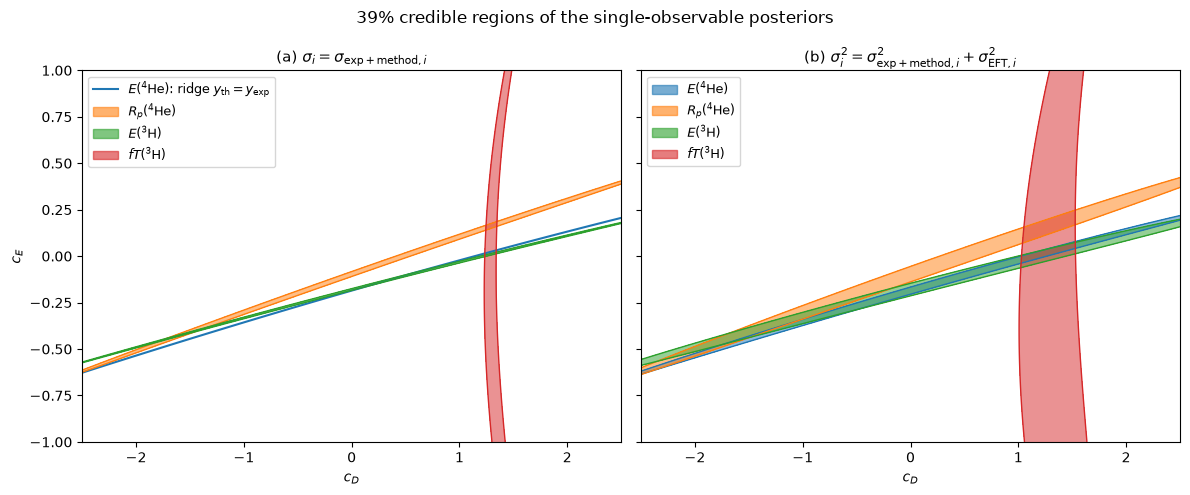

In [12]:
# Plot the posterior that follows from each individual observable, without
# (Fig. 6a) and with (Fig. 6b) the EFT truncation error.
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# The 39% region is the 2D analogue of a 1-sigma interval
credibility = 1 - np.exp(-0.5)
labels = {'E4He': r'$E(^4\mathrm{He})$', 'Rp4He': r'$R_p(^4\mathrm{He})$',
          'E3H': r'$E(^3\mathrm{H})$', 'fT3H': r'$fT(^3\mathrm{H})$'}
colors = {'E4He': 'C0', 'Rp4He': 'C1', 'E3H': 'C2', 'fT3H': 'C3'}
titles = {'exp+method': r'(a) $\sigma_i = \sigma_{\mathrm{exp+method},i}$',
          'exp+method+EFT': r'(b) $\sigma_i^2 = \sigma_{\mathrm{exp+method},i}^2'
                            r' + \sigma_{\mathrm{EFT},i}^2$'}

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (model, sigma) in zip(axs, error_models.items()):
    handles = []
    for name in exp_target:
        color = colors[name]
        if grid_step_in_sigmas(name, sigma[name]) < 1:
            # Resolved: shade the 39% highest-posterior-density region
            posterior = grid_posterior(name, sigma[name])
            level, = contour_levels(posterior, [credibility])
            ax.contourf(cD_grid, cE_grid, posterior, levels=[level, posterior.max()],
                        colors=[color], alpha=0.5)
            ax.contour(cD_grid, cE_grid, posterior, levels=[level],
                       colors=[color], linewidths=1)
            handles.append(mpatches.Patch(color=color, alpha=0.6, label=labels[name]))
        else:
            # The posterior is narrower than the grid spacing and cannot be
            # resolved. Draw the ridge y_th(cD, cE) = y_exp instead, which is
            # where it is concentrated.
            ax.contour(cD_grid, cE_grid, model_grid[name], levels=[exp_target[name]],
                       colors=[color], linewidths=1.5, linestyles='solid')
            handles.append(mlines.Line2D([], [], color=color, lw=1.5,
                                         label=labels[name] + r': ridge $y_\mathrm{th} = y_\mathrm{exp}$'))
    ax.set_title(titles[model], fontsize=11)
    ax.set_xlabel('$c_D$')
    ax.legend(handles=handles, loc='upper left', fontsize=9)
axs[0].set_ylabel('$c_E$')
fig.suptitle(f'{100 * credibility:.0f}% credible regions of the single-observable posteriors')
fig.tight_layout()

#### Interpretation

**Grid density.** Each call to the emulator takes around 60 µs, so evaluating
$10^6$ grid points would take roughly one minute. We chose an $801 \times 801$
grid, which runs in about 40 s and gives a spacing of $\Delta c_D = 0.006$ and
$\Delta c_E = 0.0025$. From the resolution table we see that this grid is fine
for seven of the eight posteriors. The exception is $E(^4\mathrm{He})$ without
the EFT truncation error: here the model prediction changes by about $7\sigma$
from one grid point to the next, which means that the band is much thinner
than the grid spacing (and actually thinner than the line width in the plot).
Because of this, in Fig. (a) we plot the ridge
$E_\mathrm{th}(c_D, c_E) = E_\mathrm{exp}$ instead of the 39% region. This
also shows that evaluating the posterior on a grid is quite inefficient when
the PDF is very narrow, since most of the grid points end up where the
posterior is basically zero.

**Fig. (a), $\sigma_i = \sigma_{\mathrm{exp+method},i}$.** When we use a single
observable we can only fix one combination of $c_D$ and $c_E$, so every
posterior looks like a narrow band and not like a closed region. The bands of
$E(^4\mathrm{He})$, $R_p(^4\mathrm{He})$ and $E(^3\mathrm{H})$ are almost
parallel and only slightly tilted. This means that these three observables are
much more sensitive to $c_E$ than to $c_D$, and that they all constrain more or
less the same combination of the two parameters. The $fT(^3\mathrm{H})$ band,
on the other hand, is almost vertical, so the beta decay mostly constrains
$c_D$. We also see that the four bands do not meet in one common point. The
$E(^4\mathrm{He})$, $E(^3\mathrm{H})$ and $fT(^3\mathrm{H})$ bands cross at
roughly the same place, but the $R_p(^4\mathrm{He})$ band crosses the
$fT(^3\mathrm{H})$ band at a clearly higher value of $c_E$, which is far away
compared to the width of the bands. So if we only include the experimental and
method errors, there is no pair $(c_D, c_E)$ that can reproduce all four
observables at once: at this level of precision the NNLO model is not accurate
enough.

**Fig. (b), with the EFT truncation error.** For all four observables the
truncation error is larger than $\sigma_{\mathrm{exp+method}}$, and the
difference is by far the biggest for $E(^4\mathrm{He})$ (see the table above).
This means that the truncation error is the main contribution to the total
error, and therefore all the bands become wider. The direction of the bands
does not change, but now they get close to a common region, where the
$fT(^3\mathrm{H})$ band crosses the other three. In this region the distance
between the bands is about the same as their width. So, once we include the
model discrepancy term, the four observables become compatible with each other.

**How many data are needed, and which combination is best?** Naively we need
two observables to determine two parameters, but only if their bands cross each
other at a large angle. The bands of $E(^4\mathrm{He})$ and $R_p(^4\mathrm{He})$
(Case 1 in Section 3) are almost parallel, and the same is true for
$E(^4\mathrm{He})$ and $E(^3\mathrm{H})$. If we combine two of these
observables, there is still a direction along the bands where the parameters
are almost not constrained, so we expect the Case 1 posterior to be very
stretched. The best pair is one of the almost horizontal bands together with
$fT(^3\mathrm{H})$, for example $E(^4\mathrm{He})$ or $E(^3\mathrm{H})$ with
$fT(^3\mathrm{H})$, since these bands cross almost at a right angle. If we use
all four observables (Case 2), we get a bit more information in the $c_E$
direction, and we can also check if the data are consistent with each other.

<a id="mcmc"></a>
## 3. MCMC sampling of the posterior

The posterior is sampled with the ensemble sampler `emcee` for two choices of
the combined data likelihood:
- Case 1: $\{E(^4\mathrm{He}), R_p(^4\mathrm{He})\}$
- Case 2: $\{E(^4\mathrm{He}), R_p(^4\mathrm{He}), E(^3\mathrm{H}), fT(^3\mathrm{H})\}$

The errors include the fixed EFT truncation errors of Section 2 and are assumed
to be independent, so the total likelihood is the product of the individual ones
(a sum of log-likelihoods). The results are shown in corner plots. Case 2
corresponds to Fig. 3 of the paper, although our distribution is somewhat
different, partly because the model discrepancy is kept fixed here.

The posterior is narrow and, in Case 1, very extended along one direction, so we
collect more than $10^5$ samples after the warm-up. The convergence is checked
with trace plots and the integrated autocorrelation time.


<div style="text-align: right"><a href="#toc">&#8593; Table of contents</a></div>

In [13]:
# Define the log prior, the log likelihood and the log posterior.
def log_prior(theta):
    """Log prior for theta = (cD, cE): independent N(0, prior_sigma^2)."""
    return np.sum(stats.norm.logpdf(theta, loc=0., scale=prior_sigma))

def log_likelihood(y_model, y_exp, sigma):
    """Log likelihood for independent normal errors: a sum over the data."""
    return np.sum(stats.norm.logpdf(y_exp, loc=y_model, scale=sigma))

def log_posterior(theta, model, y_exp, sigma):
    """Unnormalized log posterior for theta = (cD, cE)."""
    return log_prior(theta) + log_likelihood(model(theta), y_exp, sigma)

In [14]:
# Define the two data sets and the corresponding model and posterior functions.
data_sets = {'Case 1': ['E4He', 'Rp4He'],
             'Case 2': ['E4He', 'Rp4He', 'E3H', 'fT3H']}

output_index = {name: i for i, name in enumerate(model_output_names)}

def make_model(observables):
    """Return a function theta -> model predictions for the given observables."""
    indices = [output_index[name] for name in observables]
    def model(theta):
        return np.array(qs.fewnucleonEmulator(*theta))[indices]
    return model

# For each case, the extra arguments of log_posterior: the model, the data and
# the fixed total errors of Section 2 (exp + method + EFT, independent).
cases = {}
for case, observables in data_sets.items():
    y_exp = np.array([exp_target[name] for name in observables])
    sigma = np.array([sigma_total[name] for name in observables])
    cases[case] = (make_model(observables), y_exp, sigma)

In [15]:
# Test the model and log-posterior functions before starting to sample.
theta_test = np.array([qs.cD_NNLOsat, qs.cE_NNLOsat])

# The log prior at the origin is -log(2 pi sigma^2)
assert np.isclose(log_prior(np.zeros(2)), -np.log(2 * np.pi * prior_sigma**2))

for case, (model, y_exp, sigma) in cases.items():
    # The model must return the corresponding emulator outputs
    expected_output = [model_NNLOsat[output_index[name]] for name in data_sets[case]]
    assert np.allclose(model(theta_test), expected_output)
    # The log posterior must agree with the explicit Gaussian formula
    residuals = (model(theta_test) - y_exp) / sigma
    expected = (log_prior(theta_test) - 0.5 * np.sum(residuals**2)
                - np.sum(np.log(np.sqrt(2 * np.pi) * sigma)))
    value = log_posterior(theta_test, model, y_exp, sigma)
    assert np.isclose(value, expected)
    print(f'{case}: log posterior at NNLOsat = {value:.3f}')

# Time per evaluation, to plan the number of samples
n_test = 1000
start = time.perf_counter()
for _ in range(n_test):
    log_posterior(theta_test, *cases['Case 2'])
print(f'one log-posterior evaluation takes '
      f'{1e6 * (time.perf_counter() - start) / n_test:.0f} microseconds')

Case 1: log posterior at NNLOsat = -2.985
Case 2: log posterior at NNLOsat = -5.821
one log-posterior evaluation takes 114 microseconds


In [16]:
# Utility functions for the sampling and for inspecting the result.
from scipy.optimize import minimize

param_labels = [r'$c_D$', r'$c_E$']
n_dim = 2
n_walkers = 32
n_warmup = 1000   # steps per walker, discarded
n_steps = 5000    # steps per walker after the warm-up: 32 * 5000 = 1.6e5 samples
# At ~100 microseconds per evaluation, one run takes about 20 s.

def find_map(case, theta_start=(qs.cD_NNLOsat, qs.cE_NNLOsat)):
    """Maximum a posteriori point, used as the starting point of the walkers."""
    result = minimize(lambda theta: -log_posterior(theta, *cases[case]), theta_start,
                      method='Nelder-Mead', options={'xatol': 1e-6, 'fatol': 1e-8})
    return result.x

def run_sampler(case, theta_start, seed):
    """Sample the posterior of `case`, starting in a small ball around theta_start."""
    p0 = np.random.default_rng(seed).normal(theta_start, 1e-2, size=(n_walkers, n_dim))
    sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior, args=cases[case])
    # emcee uses NumPy's legacy random state, not a Generator: set it explicitly
    # to make the run reproducible.
    sampler.random_state = np.random.RandomState(seed).get_state()
    sampler.run_mcmc(p0, n_warmup + n_steps, progress=False)
    return sampler

def summarize(sampler):
    """Print convergence diagnostics and credible intervals; return the samples."""
    samples = sampler.get_chain(discard=n_warmup, flat=True)
    tau = sampler.get_autocorr_time(discard=n_warmup, tol=0)
    print(f'{len(samples)} samples after warm-up, mean acceptance fraction '
          f'{np.mean(sampler.acceptance_fraction):.2f}')
    print('autocorrelation time: ' + ', '.join(f'{t:.0f}' for t in tau)
          + f' steps, i.e. ~{len(samples) / tau.max():.0f} independent samples')
    for name, (p16, p50, p84) in zip(['cD', 'cE'],
                                     np.percentile(samples, [16, 50, 84], axis=0).T):
        print(f'{name} = {p50:.3f} +{p84 - p50:.3f} -{p50 - p16:.3f} '
              f'(median and 68% credible interval)')
    print(f'correlation coefficient of cD and cE: {np.corrcoef(samples.T)[0, 1]:.3f}')
    return samples

def plot_traces(sampler, title, labels=param_labels):
    """Trace of every walker for each parameter, with the warm-up shaded."""
    chain = sampler.get_chain()
    fig, axs = plt.subplots(len(labels), 1, figsize=(10, 1 + 2 * len(labels)), sharex=True)
    for i, ax in enumerate(axs):
        ax.plot(chain[:, :, i], color='k', alpha=0.1, lw=0.5)
        ax.axvspan(0, n_warmup, color='C1', alpha=0.2, label='warm-up (discarded)')
        ax.set_ylabel(labels[i])
    axs[0].legend(loc='upper right')
    axs[0].set_title(title)
    axs[-1].set_xlabel('step')
    fig.tight_layout()

def plot_corner(samples, title):
    """Corner plot with the median and the 68% credible interval of each parameter."""
    fig = corner.corner(samples, labels=param_labels, quantiles=[0.16, 0.5, 0.84],
                        show_titles=True, title_fmt='.3f', bins=50)
    fig.suptitle(title, y=1.04)

MAP: cD = -2.280, cE = -0.584


160000 samples after warm-up, mean acceptance fraction 0.69
autocorrelation time: 42, 41 steps, i.e. ~3846 independent samples
cD = -1.681 +2.332 -2.139 (median and 68% credible interval)
cE = -0.473 +0.410 -0.412 (median and 68% credible interval)
correlation coefficient of cD and cE: 0.995


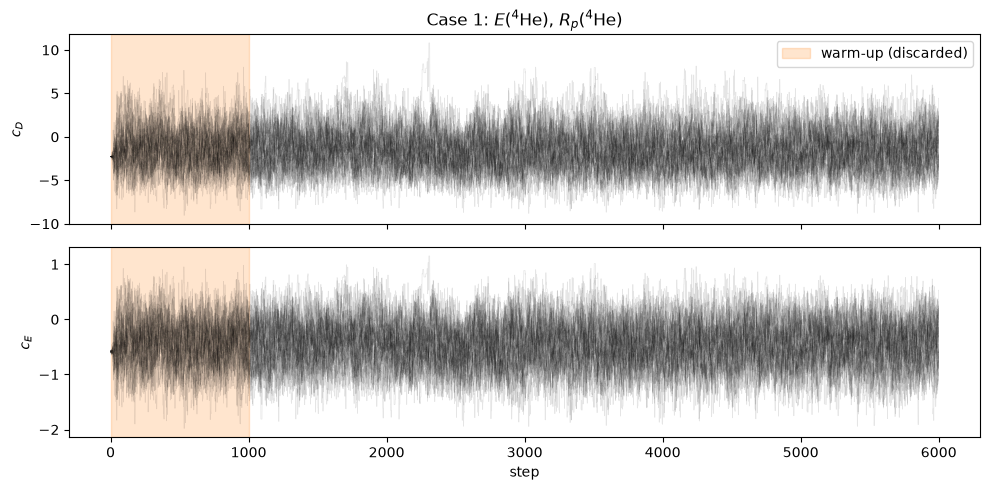

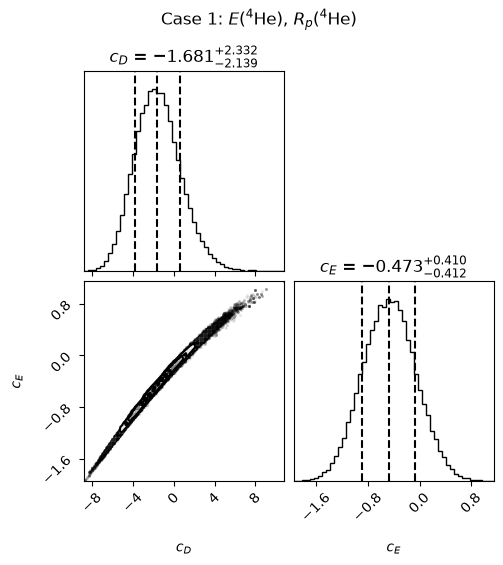

In [17]:
# Case 1: E4He + Rp4He
theta_map_1 = find_map('Case 1')
print(f'MAP: cD = {theta_map_1[0]:.3f}, cE = {theta_map_1[1]:.3f}')

sampler_1 = run_sampler('Case 1', theta_map_1, seed=1)
samples_1 = summarize(sampler_1)
plot_traces(sampler_1, r'Case 1: $E(^4\mathrm{He})$, $R_p(^4\mathrm{He})$')
plot_corner(samples_1, r'Case 1: $E(^4\mathrm{He})$, $R_p(^4\mathrm{He})$')

MAP: cD = 1.126, cE = 0.011


160000 samples after warm-up, mean acceptance fraction 0.71
autocorrelation time: 32, 32 steps, i.e. ~4966 independent samples
cD = 1.166 +0.471 -0.471 (median and 68% credible interval)
cE = 0.016 +0.079 -0.080 (median and 68% credible interval)
correlation coefficient of cD and cE: 0.936


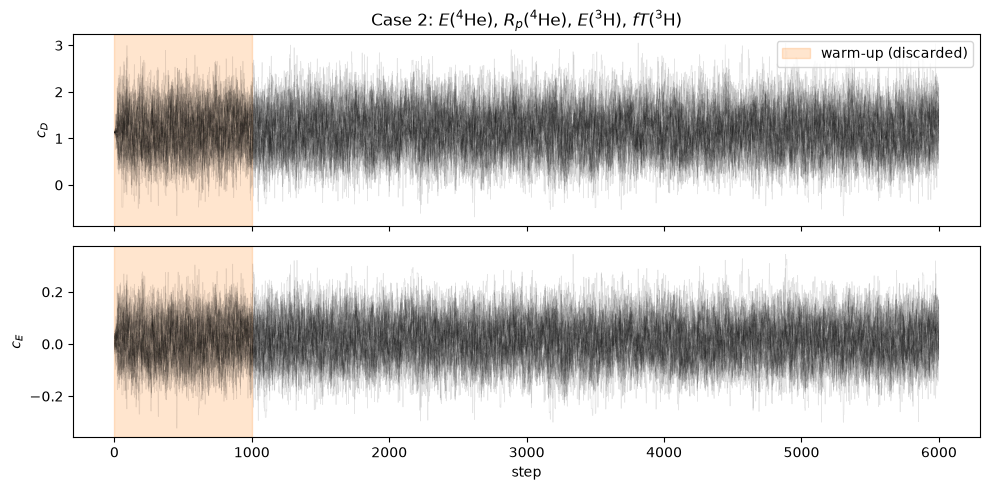

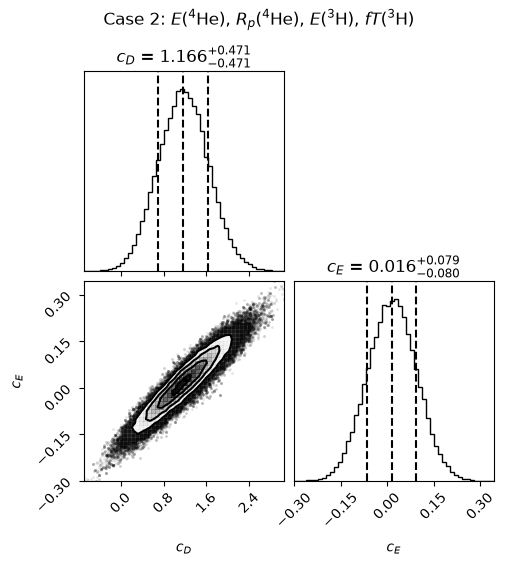

In [18]:
# Case 2: E4He + Rp4He + E3H + fT3H
theta_map_2 = find_map('Case 2')
print(f'MAP: cD = {theta_map_2[0]:.3f}, cE = {theta_map_2[1]:.3f}')

sampler_2 = run_sampler('Case 2', theta_map_2, seed=2)
samples_2 = summarize(sampler_2)
plot_traces(sampler_2, r'Case 2: $E(^4\mathrm{He})$, $R_p(^4\mathrm{He})$, '
                       r'$E(^3\mathrm{H})$, $fT(^3\mathrm{H})$')
plot_corner(samples_2, r'Case 2: $E(^4\mathrm{He})$, $R_p(^4\mathrm{He})$, '
                       r'$E(^3\mathrm{H})$, $fT(^3\mathrm{H})$')

#### Interpretation

**Convergence.** The walkers start in a small ball around the MAP point and
spread over the whole posterior after only a few steps. After that the traces
do not show any trend and all walkers move in the same region, so the 1000
warm-up steps that we discard are much longer than the autocorrelation time
(about 41 steps in Case 1 and 32 in Case 2). The 5000 steps that we keep for
each walker give $1.6 \cdot 10^5$ samples per case.

**Case 1: $E(^4\mathrm{He})$ and $R_p(^4\mathrm{He})$.** The posterior is a
thin and slightly curved ridge, and $c_D$ and $c_E$ are almost perfectly
correlated (correlation coefficient 0.995). The marginal credible intervals are
very wide: $c_D = -1.68^{+2.33}_{-2.14}$ and $c_E = -0.47 \pm 0.41$. As we
expected from Section 2, the two observables give almost parallel bands, so the
data only fix the combination of $c_D$ and $c_E$ across the ridge. With this
data set we cannot determine $c_D$ and $c_E$ separately.

**Case 2: all four observables.** When we add $E(^3\mathrm{H})$ and especially
$fT(^3\mathrm{H})$, the posterior becomes compact and close to a Gaussian:
$c_D = 1.17 \pm 0.47$ and $c_E = 0.016^{+0.079}_{-0.080}$. The beta decay fixes
$c_D$, and the other three observables then fix $c_E$. Since these three
constrain nearly the same combination of the two parameters, $c_D$ and $c_E$
are still strongly correlated (correlation coefficient 0.94).

**Comparison with Fig. 3 of the paper.** The shape is similar: also in the
paper $c_D$ and $c_E$ are strongly and positively correlated. The position of
the posterior is different, which is expected since our model is slightly
different and the NN LECs are fixed. Our posterior is also narrower and has
Gaussian tails, while the paper finds heavier tails (a multivariate $t$
distribution). The reason is that the paper also samples $Q$ and $\bar c$. Here
the truncation error is fixed, and, as the paper points out, this makes the
credible intervals narrower than they should be.

<a id="ppd"></a>
## 4. Posterior predictive distribution

Using the posterior samples obtained with the full data set (Case 2 of
Section 3), we compute the posterior predictive distribution for the four
observables and show it in a corner plot, similar to Fig. 4 of the paper (again
with some differences, partly due to the fixed model discrepancy). We then
compare it with the prior predictive distribution of Section 1 to quantify how
much the data have narrowed the predictions.

Since the predicted observables are the same ones that were used to calibrate
the model, this is a form of model checking: it tests that the model is
consistent and that the data analysis worked.


<div style="text-align: right"><a href="#toc">&#8593; Table of contents</a></div>

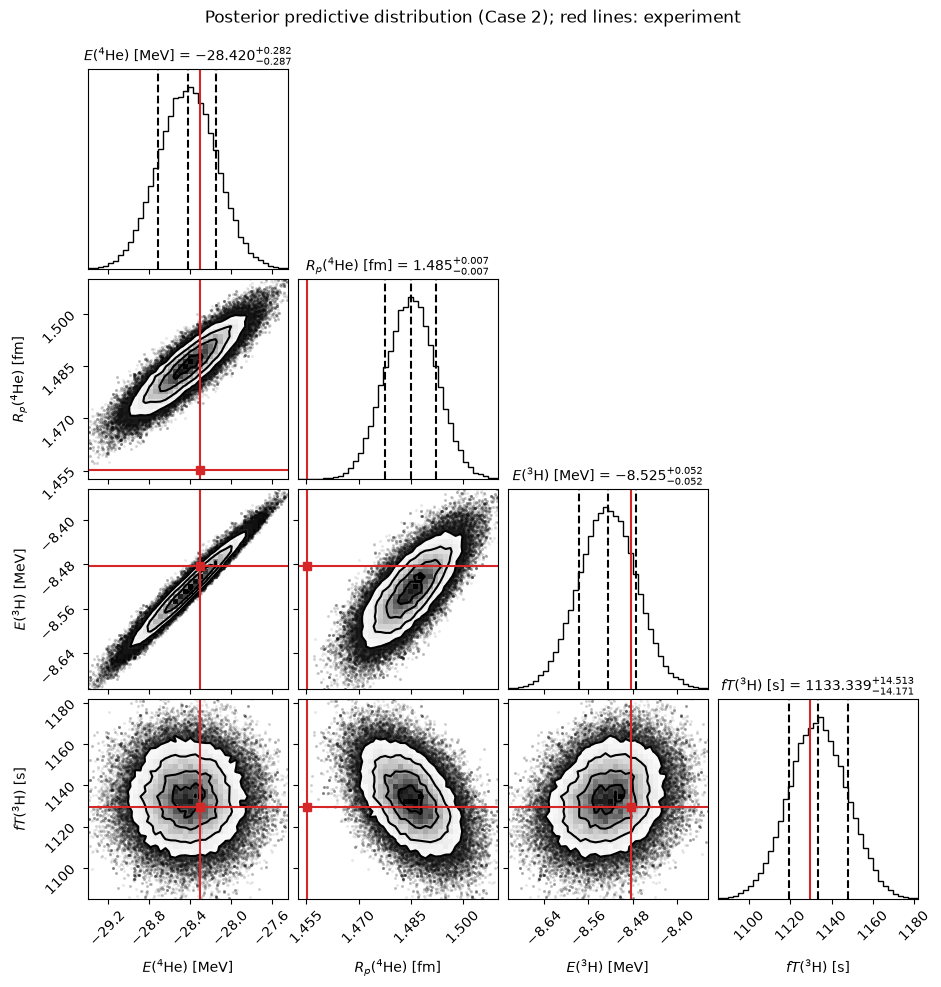

In [19]:
# Posterior predictive distribution for the four Case 2 observables.
# As in Eq. (24) of the paper, the ppd is the set of model predictions
# y_th(cD, cE) for (cD, cE) drawn from the posterior. We use all 1.6e5 Case 2
# samples (about 10 s).
ppd_names = data_sets['Case 2']
ppd_output = vfewnucleonEmulator(samples_2[:, 0], samples_2[:, 1])
posterior_predictive = {name: ppd_output[output_index[name]] for name in ppd_names}
ppd_samples = np.column_stack([posterior_predictive[name] for name in ppd_names])
y_exp_2 = cases['Case 2'][1]

# Extend the plot ranges so that the experimental values are always visible
lo = np.minimum(np.percentile(ppd_samples, 0.1, axis=0), y_exp_2)
hi = np.maximum(np.percentile(ppd_samples, 99.9, axis=0), y_exp_2)
pad = 0.05 * (hi - lo)
ppd_labels = [r'$E(^4\mathrm{He})$ [MeV]', r'$R_p(^4\mathrm{He})$ [fm]',
              r'$E(^3\mathrm{H})$ [MeV]', r'$fT(^3\mathrm{H})$ [s]']

fig = corner.corner(ppd_samples, labels=ppd_labels, range=list(zip(lo - pad, hi + pad)),
                    quantiles=[0.16, 0.5, 0.84], show_titles=True, title_fmt='.3f',
                    title_kwargs={'fontsize': 10}, truths=y_exp_2, truth_color='C3',
                    bins=40)
fig.suptitle('Posterior predictive distribution (Case 2); red lines: experiment', y=1.02)
plt.show()

In [20]:
# Comparison with experiment, and with the prior predictive distribution of Section 1.
print('Posterior predictive distribution compared with experiment:')
print(f"{'':>6} {'median':>10} {'68% interval':>22} {'95% interval':>22} "
      f"{'experiment':>11} {'(median-exp)/sigma_total':>25}")
for name in ppd_names:
    p2, p16, p50, p84, p97 = np.percentile(posterior_predictive[name], [2.5, 16, 50, 84, 97.5])
    print(f'{name:>6} {p50:>10.4f}  [{p16:>9.4f}, {p84:>9.4f}]  [{p2:>9.4f}, {p97:>9.4f}] '
          f'{exp_target[name]:>11.4f} {(p50 - exp_target[name]) / sigma_total[name]:>25.2f}')

print('\nWidth of the central 68% interval, prior vs. posterior predictive:')
print(f"{'':>6} {'prior':>10} {'posterior':>10} {'narrowed by':>12}")
for name in ppd_names:
    width_prior = np.diff(np.percentile(prior_predictive[name], [16, 84]))[0]
    width_post = np.diff(np.percentile(posterior_predictive[name], [16, 84]))[0]
    print(f'{name:>6} {width_prior:>10.3f} {width_post:>10.4f} {width_prior / width_post:>11.0f}x')

Posterior predictive distribution compared with experiment:
           median           68% interval           95% interval  experiment  (median-exp)/sigma_total
  E4He   -28.4200  [ -28.7067,  -28.1383]  [ -28.9824,  -27.8632]    -28.2960                     -0.35
 Rp4He     1.4851  [   1.4776,    1.4923]  [   1.4708,    1.4994]      1.4552                      1.55
   E3H    -8.5254  [  -8.5778,   -8.4733]  [  -8.6284,   -8.4217]     -8.4820                     -0.40
  fT3H  1133.3392  [1119.1687, 1147.8523]  [1105.4156, 1161.3815]   1129.6000                      0.26

Width of the central 68% interval, prior vs. posterior predictive:
            prior  posterior  narrowed by
  E4He    475.312     0.5684         836x
 Rp4He      1.097     0.0147          74x
   E3H     70.297     0.1045         673x
  fT3H    903.161    28.6836          31x


#### Interpretation

**The posterior predictive distribution.** For $E(^4\mathrm{He})$,
$E(^3\mathrm{H})$ and $fT(^3\mathrm{H})$ the experimental value falls inside the
central 68% interval of the prediction, so the model reproduces these three
observables well. The two binding energies are strongly correlated with each
other: in the corner plot their joint distribution is a narrow diagonal band,
and the experimental point lies right on it. $fT(^3\mathrm{H})$, instead, is
only weakly correlated with the energies, since it depends on a different
combination of the parameters. The only exception is $R_p(^4\mathrm{He})$. Here
the model predicts a radius that is clearly larger than the measured one, and
the experimental value is even outside the 95% interval of the prediction.

**Model checking.** We have to keep in mind that the posterior predictive
distribution only includes the uncertainty of the parameters. Our error model,
however, also allows each prediction to differ from the experiment by the
truncation error, so the right way to compare is in units of
$\sigma_{\mathrm{total},i}$. In these units the medians differ from the
experimental values by $-0.35$ for $E(^4\mathrm{He})$, $1.55$ for
$R_p(^4\mathrm{He})$, $-0.40$ for $E(^3\mathrm{H})$ and $0.26$ for
$fT(^3\mathrm{H})$. So, once the truncation error is taken into account, the
calibrated model describes all four observables consistently, and we can
conclude that the analysis worked. The largest deviation is the one for the
radius, and it is the same tension that we already saw in Section 2, where the
$R_p(^4\mathrm{He})$ band crosses the $fT(^3\mathrm{H})$ band away from the
other three.

**Comparison with the prior predictive distribution.** Compared with Section 1,
the central 68% intervals are much narrower: by a factor of about 836 for
$E(^4\mathrm{He})$, 673 for $E(^3\mathrm{H})$, 74 for $R_p(^4\mathrm{He})$ and
31 for $fT(^3\mathrm{H})$. The binding energies are narrowed the most, which
makes sense because their prior predictive distributions were the widest. After
conditioning on the data, the spread of each prediction is comparable to or
smaller than its truncation error from Section 2.

**Comparison with Fig. 4 of the paper.** Our distributions are narrower than
the ones in the paper (Fig. 4 and Table I). This is because we keep $Q$,
$\bar c$ and the NN LECs fixed, while the paper samples or marginalizes over
them. In the paper all four experimental values are within one standard
deviation of the marginals, including the radius, while with our slightly
different model the radius comes out too large.

<a id="errormodel"></a>
## 5. Inferring the error model

So far the model-discrepancy term has been fixed. Within the Bayesian framework
its uncertainty can be included in the analysis in a straightforward way: the
expansion parameter $Q$, which enters the variance of the truncation error, is
treated as a model parameter. (In the paper by Wesolowski *et al.* also the
scale $\bar{c}$ is inferred; here it is kept fixed.)

We therefore infer the joint posterior for $(c_D, c_E, Q)$ given the Case 2
data, with $\sigma_\mathrm{EFT}$ no longer fixed. Following the arguments on
page 4 of the paper, the prior for $Q$ is a weakly informative Beta
distribution, $p(Q|I) = B(Q | a = 3, b = 5)$. The results are compared with
Figs. 3, 4 and 5 of the paper (although $\bar{c}$ is not varied here).

The variance of the truncation error, $\propto Q^{2k+2}/(1-Q^2)$, is negative
for $Q > 1$, so proposals with $Q$ outside $(0, 1)$ are rejected before the
likelihood is evaluated.


<div style="text-align: right"><a href="#toc">&#8593; Table of contents</a></div>

In [21]:
# The prior for the EFT expansion parameter Q.
Q_prior = stats.beta(a=3, b=5)

print(f'prior for Q: median {Q_prior.median():.3f}, 68% interval '
      f'[{Q_prior.ppf(0.16):.3f}, {Q_prior.ppf(0.84):.3f}]')

prior for Q: median 0.364, 68% interval [0.207, 0.545]


In [22]:
# Log likelihood and log posterior with the EFT truncation error controlled by
# the extra model parameter Q.
param_labels_Q = [r'$c_D$', r'$c_E$', r'$Q$']
model_2, y_exp_2, _ = cases['Case 2']
sigma_exp_method_2 = np.array([exp_method_error[name] for name in data_sets['Case 2']])

def log_prior_Q(theta):
    """Log prior for theta = (cD, cE, Q): the prior of Section 1 times Beta(3, 5) for Q."""
    return log_prior(theta[:2]) + Q_prior.logpdf(theta[2])

def log_likelihood_Q(theta):
    """Case 2 log likelihood, with the truncation error set by Q."""
    sigma = np.sqrt(sigma_exp_method_2**2 + eft_truncation_error(y_exp_2, Q=theta[2])**2)
    return log_likelihood(model_2(theta[:2]), y_exp_2, sigma)

def log_posterior_Q(theta):
    """Unnormalized log posterior for theta = (cD, cE, Q)."""
    # The truncation-error variance is negative for Q > 1 and the prior vanishes
    # outside (0, 1): reject such proposals before evaluating the likelihood.
    if not 0 < theta[2] < 1:
        return -np.inf
    return log_prior_Q(theta) + log_likelihood_Q(theta)

# Tests: at Q = 0.33 the likelihood is the Case 2 likelihood of Section 3, and
# proposals with Q outside (0, 1) are rejected.
theta_test_Q = np.append(theta_test, 0.33)
assert np.isclose(log_likelihood_Q(theta_test_Q),
                  log_posterior(theta_test, *cases['Case 2']) - log_prior(theta_test))
assert log_posterior_Q(np.append(theta_test, 1.2)) == -np.inf
assert log_posterior_Q(np.append(theta_test, -0.1)) == -np.inf

240000 samples after warm-up, mean acceptance fraction 0.62
autocorrelation time: 45, 45, 47 steps, i.e. ~5090 independent samples
cD = 1.170 +0.725 -0.655 (median and 68% credible interval)
cE = 0.013 +0.119 -0.115 (median and 68% credible interval)
Q = 0.359 +0.061 -0.044 (median and 68% credible interval)


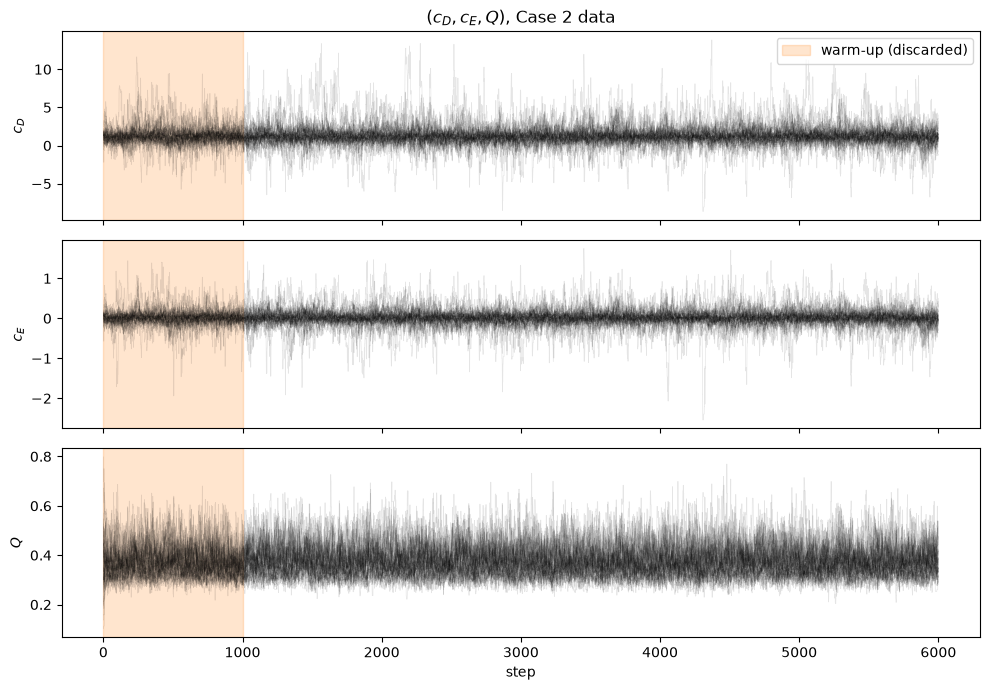

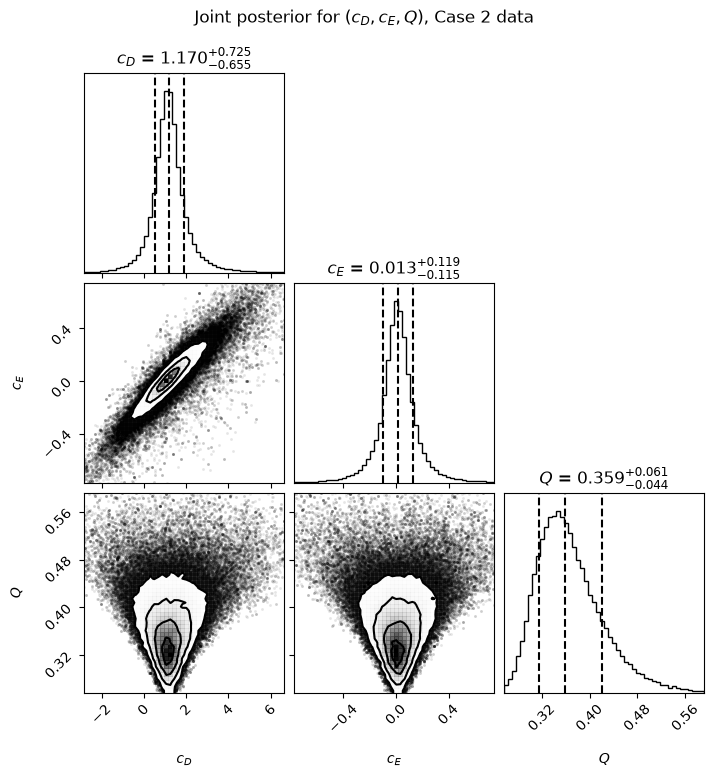

In [23]:
# Sample the joint posterior for (cD, cE, Q).
# The walkers start from Case 2 samples of Section 3, with Q drawn from its prior,
# which saves a long warm-up. With one more parameter we use more walkers than
# in Section 3 (about 45 s).
n_walkers_Q = 48
seed_Q = 3
init_rng = np.random.default_rng(seed_Q)
p0_Q = np.column_stack([samples_2[init_rng.choice(len(samples_2), n_walkers_Q)],
                        Q_prior.rvs(size=n_walkers_Q, random_state=init_rng)])
sampler_Q = emcee.EnsembleSampler(n_walkers_Q, len(param_labels_Q), log_posterior_Q)
sampler_Q.random_state = np.random.RandomState(seed_Q).get_state()
sampler_Q.run_mcmc(p0_Q, n_warmup + n_steps, progress=False)

samples_Q = sampler_Q.get_chain(discard=n_warmup, flat=True)
tau_Q = sampler_Q.get_autocorr_time(discard=n_warmup, tol=0)
print(f'{len(samples_Q)} samples after warm-up, mean acceptance fraction '
      f'{np.mean(sampler_Q.acceptance_fraction):.2f}')
print('autocorrelation time: ' + ', '.join(f'{t:.0f}' for t in tau_Q)
      + f' steps, i.e. ~{len(samples_Q) / tau_Q.max():.0f} independent samples')
for name, (p16, p50, p84) in zip(['cD', 'cE', 'Q'],
                                 np.percentile(samples_Q, [16, 50, 84], axis=0).T):
    print(f'{name} = {p50:.3f} +{p84 - p50:.3f} -{p50 - p16:.3f} '
          f'(median and 68% credible interval)')

plot_traces(sampler_Q, r'$(c_D, c_E, Q)$, Case 2 data', labels=param_labels_Q)
# The marginals of cD and cE have long tails: show the central 99.5% of the samples
fig = corner.corner(samples_Q, labels=param_labels_Q, quantiles=[0.16, 0.5, 0.84],
                    show_titles=True, title_fmt='.3f', bins=50, range=[0.995] * 3)
fig.suptitle(r'Joint posterior for $(c_D, c_E, Q)$, Case 2 data', y=1.03)
plt.show()

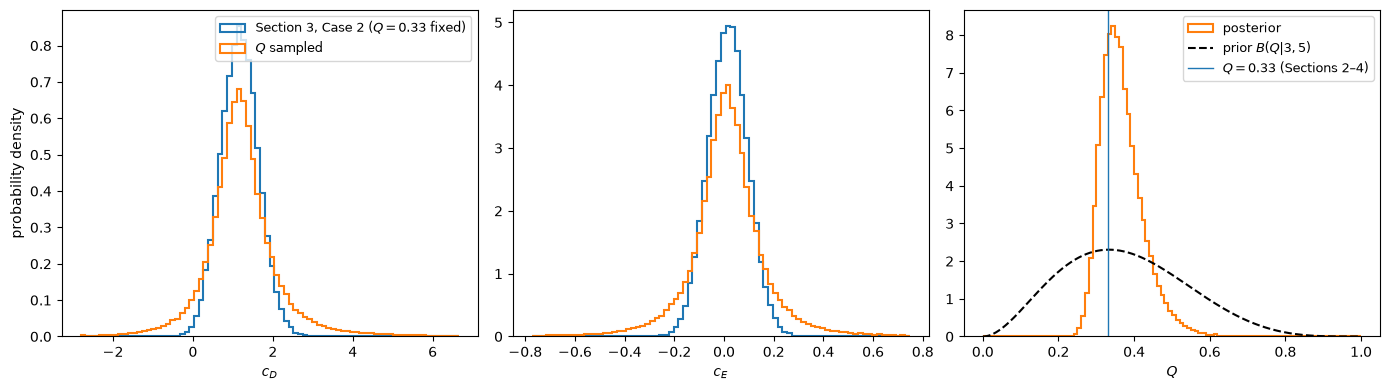

                 median         68% interval         95% interval
 cD    Q fixed    1.166  [  0.696,   1.637]  [  0.267,   2.108]
 cD  Q sampled    1.170  [  0.516,   1.896]  [ -0.639,   3.458]
 cE    Q fixed    0.016  [ -0.064,   0.094]  [ -0.139,   0.171]
 cE  Q sampled    0.013  [ -0.103,   0.132]  [ -0.331,   0.357]
  Q      prior    0.364  [  0.207,   0.545]  [  0.099,   0.710]
  Q  posterior    0.359  [  0.316,   0.420]  [  0.283,   0.502]
correlation coefficient of cD and cE: 0.899 (Q sampled), 0.936 (Q fixed)


In [24]:
# Compare the marginal distributions with those of Section 3, and compare the
# prior and the posterior for Q.
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
for i, ax in enumerate(axs[:2]):
    lo, hi = np.percentile(samples_Q[:, i], [0.25, 99.75])
    for samples, label in [(samples_2[:, i], 'Section 3, Case 2 ($Q = 0.33$ fixed)'),
                           (samples_Q[:, i], '$Q$ sampled')]:
        # Normalized to the full sample, not only to the part shown
        bin_width = (hi - lo) / 80
        ax.hist(samples, bins=80, range=(lo, hi), histtype='step', lw=1.5, label=label,
                weights=np.full(len(samples), 1. / (len(samples) * bin_width)))
    ax.set_xlabel(param_labels_Q[i])
axs[0].set_ylabel('probability density')
axs[0].legend(fontsize=9)

Q_values = np.linspace(0, 1, 401)
axs[2].hist(samples_Q[:, 2], bins=100, range=(0, 1), density=True, histtype='step',
            lw=1.5, color='C1', label='posterior')
axs[2].plot(Q_values, Q_prior.pdf(Q_values), 'k--', label='prior $B(Q | 3, 5)$')
axs[2].axvline(0.33, color='C0', lw=1, label='$Q = 0.33$ (Sections 2–4)')
axs[2].set_xlabel('$Q$')
axs[2].legend(fontsize=9)
fig.tight_layout()
plt.show()

print(f"{'':>3} {'':>10} {'median':>8} {'68% interval':>20} {'95% interval':>20}")
for i, name in enumerate(['cD', 'cE']):
    for label, samples in [('Q fixed', samples_2[:, i]), ('Q sampled', samples_Q[:, i])]:
        p2, p16, p50, p84, p97 = np.percentile(samples, [2.5, 16, 50, 84, 97.5])
        print(f'{name:>3} {label:>10} {p50:>8.3f}  [{p16:>7.3f}, {p84:>7.3f}]  '
              f'[{p2:>7.3f}, {p97:>7.3f}]')
for label, (p2, p16, p50, p84, p97) in [
        ('prior', Q_prior.ppf([0.025, 0.16, 0.5, 0.84, 0.975])),
        ('posterior', np.percentile(samples_Q[:, 2], [2.5, 16, 50, 84, 97.5]))]:
    print(f'{"Q":>3} {label:>10} {p50:>8.3f}  [{p16:>7.3f}, {p84:>7.3f}]  '
          f'[{p2:>7.3f}, {p97:>7.3f}]')
print(f'correlation coefficient of cD and cE: {np.corrcoef(samples_Q[:, :2].T)[0, 1]:.3f} '
      f'(Q sampled), {np.corrcoef(samples_2.T)[0, 1]:.3f} (Q fixed)')

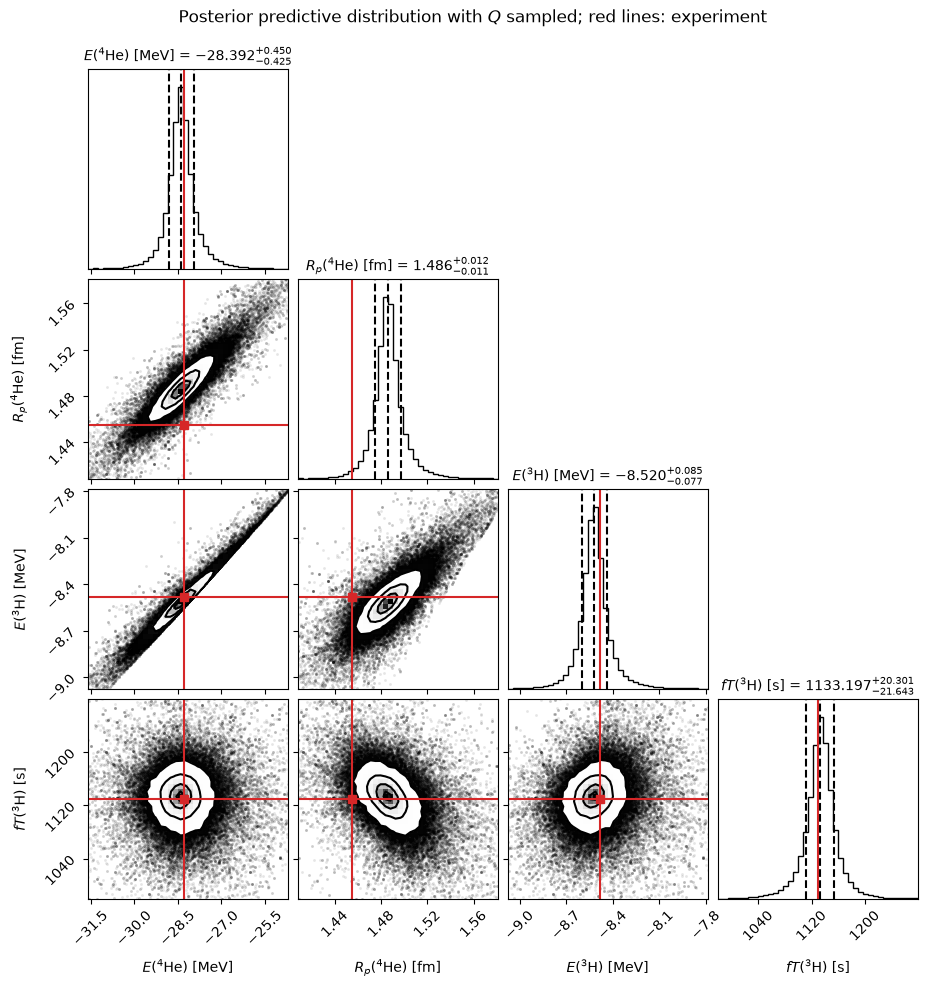

        68% width, Q fixed  68% width, Q sampled   95% interval, Q sampled  experiment
  E4He              0.5684                0.8752   [ -29.6075,  -26.9456]    -28.2960
 Rp4He              0.0147                0.0225   [   1.4557,    1.5230]      1.4552
   E3H              0.1045                0.1625   [  -8.7384,   -8.2392]     -8.4820
  fT3H             28.6836               41.9447   [1068.3164, 1190.8608]   1129.6000


In [25]:
# Posterior predictive distribution with the sampled error model.
# As in Section 4, but with the (cD, cE) samples of the joint posterior (about 15 s).
# Q only enters the error model, not the model predictions.
ppd_output_Q = vfewnucleonEmulator(samples_Q[:, 0], samples_Q[:, 1])
posterior_predictive_Q = {name: ppd_output_Q[output_index[name]] for name in ppd_names}
ppd_samples_Q = np.column_stack([posterior_predictive_Q[name] for name in ppd_names])

# Long tails: show the central 99.5% of the samples, and always the experiment
lo = np.minimum(np.percentile(ppd_samples_Q, 0.25, axis=0), y_exp_2)
hi = np.maximum(np.percentile(ppd_samples_Q, 99.75, axis=0), y_exp_2)
pad = 0.05 * (hi - lo)
fig = corner.corner(ppd_samples_Q, labels=ppd_labels, range=list(zip(lo - pad, hi + pad)),
                    quantiles=[0.16, 0.5, 0.84], show_titles=True, title_fmt='.3f',
                    title_kwargs={'fontsize': 10}, truths=y_exp_2, truth_color='C3',
                    bins=40)
fig.suptitle('Posterior predictive distribution with $Q$ sampled; red lines: experiment',
             y=1.02)
plt.show()

print(f"{'':>6} {'68% width, Q fixed':>19} {'68% width, Q sampled':>21} "
      f"{'95% interval, Q sampled':>25} {'experiment':>11}")
for name in ppd_names:
    width_fixed = np.diff(np.percentile(posterior_predictive[name], [16, 84]))[0]
    width_sampled = np.diff(np.percentile(posterior_predictive_Q[name], [16, 84]))[0]
    p2, p97 = np.percentile(posterior_predictive_Q[name], [2.5, 97.5])
    print(f'{name:>6} {width_fixed:>19.4f} {width_sampled:>21.4f}   '
          f'[{p2:>9.4f}, {p97:>9.4f}] {exp_target[name]:>11.4f}')

#### Interpretation

**Convergence.** Like in Section 3, after the warm-up the traces do not show any
trend and all the walkers move in the same region. The autocorrelation times
(45–47 steps) are much shorter than the 1000 warm-up steps, and the 240000
samples that we keep correspond to about 5000 independent samples. Compared
with Section 3, the traces of $c_D$ and $c_E$ sometimes make large jumps away from
the centre. This is not a problem of the sampling, but a consequence of the
long tails of the posterior, which we discuss below.

**Shape of the distributions.** The marginals of $c_D$ and $c_E$ have almost
the same median as in Section 3, but their shape is different: now they have long
tails, while in Section 3 they were close to Gaussian. The 68% intervals become a
bit wider (for $c_D$ from $[0.70, 1.64]$ to $[0.52, 1.90]$), but the 95%
intervals become much wider (from $[0.27, 2.11]$ to $[-0.64, 3.46]$). We can
understand why by looking at the corner plot. For a fixed value of $Q$ the
posterior for $(c_D, c_E)$ is close to a Gaussian, but its width grows quickly
with $Q$, since the truncation error grows like $Q^{k+1}$. This gives the
funnel shape in the $(c_D, Q)$ and $(c_E, Q)$ panels. When we marginalize over
$Q$ we are mixing narrow Gaussians (small $Q$) with wide ones (large $Q$), and a
mixture like this has much heavier tails than a single Gaussian. The
correlation between $c_D$ and $c_E$ is still strong (0.899, compared with 0.936
when $Q$ is fixed).

**Are we learning anything about $Q$?** Yes. The posterior for $Q$ is much
narrower than the Beta prior: its 68% interval is $[0.316, 0.420]$, while for
the prior it is $[0.207, 0.545]$. Small values of $Q$ are excluded, because
then the truncation error would be too small to make the four observables
compatible with each other. This is the same tension that we saw in Fig. (a) of
Section 2. Large values of $Q$ are also disfavoured: a larger error makes the
likelihood broader and therefore lower at the observed data, and the four
observables are already reproduced well with a moderate truncation error. The
posterior has its peak close to $Q = 0.33$, which is the value that we used in
Sections 2–4.

**Comparison with Figs. 3, 4 and 5 of the paper.** When we sample $Q$, our
$(c_D, c_E)$ posterior gets the long tails that the paper describes with a
multivariate $t$ distribution in Fig. 3, and it becomes wider than in Section 3.
Its position is still different, as expected. The posterior predictive
distribution also becomes wider (for example, the 68% width for
$E(^4\mathrm{He})$ goes from 0.57 to 0.88 MeV), and now the widths are close to
the intervals in Fig. 4 and Table I of the paper. The experimental radius is
now just below the lower end of the 95% interval of the prediction, and not far
outside it as before. Finally, as in Fig. 5 of the paper, the posterior for $Q$
is much narrower than the prior and lies close to 0.33. However, in the paper
$Q$ is also constrained by the shift between the NLO and NNLO predictions,
which we do not use here.